### Time Sereis Forecasting on a Sales data

In [ ]:
# Importing the basic modules to play with datasets



import pandas as pd
import numpy as np


# Visualization library
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Reading the dataset as DataFrame

df = pd.read_csv('data.csv')

In [ ]:
#Info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
# Top 2 results in the dataset

df.head(2)

,Month,#Passengers
0,1949-01,112
1,1949-02,118


In [ ]:
#Check for null or empty values

df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [ ]:
#Check for duplicated values

df.duplicated().sum()

0

In [ ]:
# Converting the month column string to date time data type

df.Month = pd.to_datetime(df.Month)

In [ ]:
# Sorting the dataset by ascending order with respect to month

df.sort_values(by='Month', inplace=True)

In [ ]:
# Setting the index as month

df.set_index('Month', inplace=True)

<Axes: xlabel='Month'>

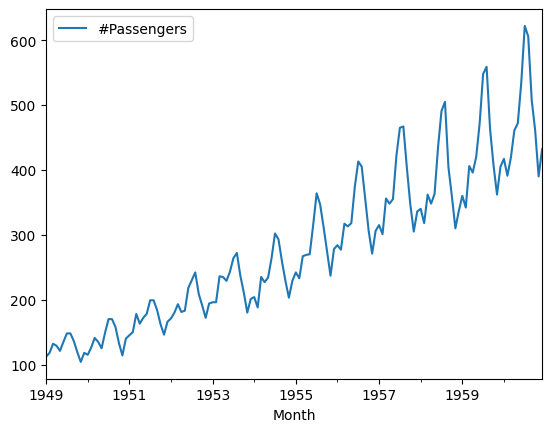

In [ ]:
#Visual representation of the data

df.plot()

Figure(640x480)


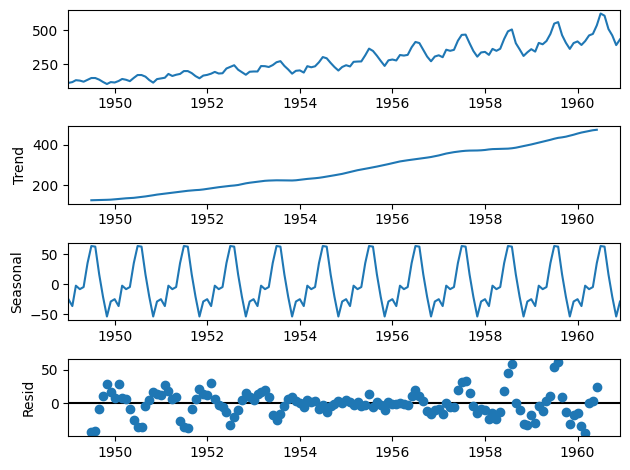

In [ ]:
# Seasonal decompose the dataset to see season, Trend and Noise(Residual)

from statsmodels.tsa.seasonal import seasonal_decompose  #Importing the seasonal_decompose package

decompose = seasonal_decompose(df)

print(decompose.plot())

In [ ]:
# Grouping the dataset by month

df = df.groupby(pd.Grouper(freq='M')).sum()

In [ ]:
# Hypothesis testing to find the data is staionary or not stationary
# Adfuller gives the list value, where the second value is pvalue. From the pvalue we can conclude the data is stationary or not. 
# If the pvalue is greater than 0.5 the data is not statinary, if the pvalue is less that 0.5 the data is stationary.

from statsmodels.tsa.stattools import adfuller 

def hypothesis_testing(df):
    p_value = adfuller(df)
    if p_value[1] <0.5:
        print('Failed to Reject null hypothesis, Data is stationary')
    else:
        print('Reject null hypothesis, Data is not stationary')

In [ ]:
# Calling the hypothesis function to check the data is stationary or not.

hypothesis_testing(df)

Reject null hypothesis, Data is not stationary


 Hypothesis testing has verified that the data is not stationary.

The first step is to divide the data into training and testing sets, followed by making the training data stationary.

Stationary data is the ideal format for training a time series model, ensuring the development of a reliable and accurate model.



If the model is not statinory, the reasons are:

1. The mean is varying and
2. Varying variance.


In [ ]:
# Splitting the training and testing data

df_train = df[0:-5]
df_test = df[-5:]

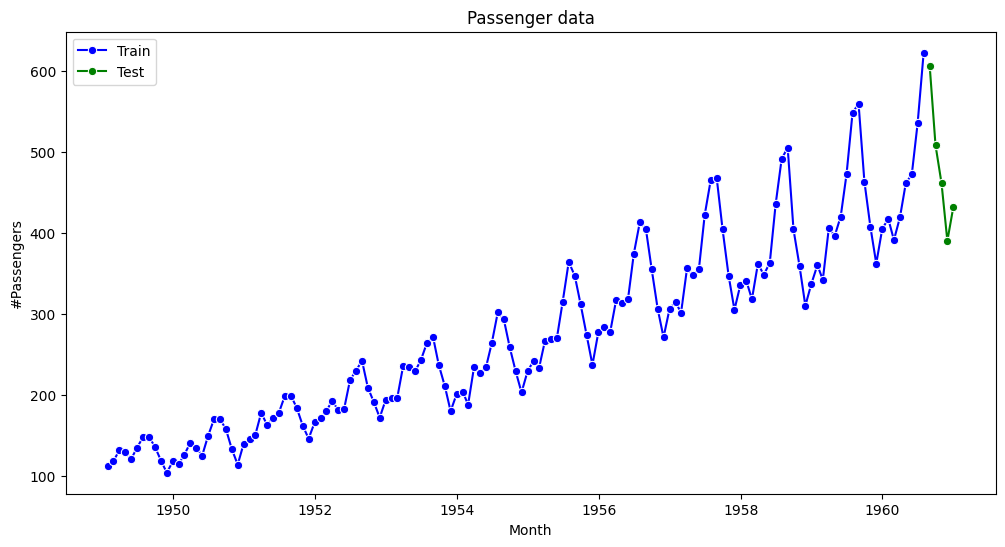

In [ ]:
# Visualising the training and testing data using seaborn.


plt.figure(figsize=(12, 6))
sns.lineplot(data = df_train, x= 'Month', y = '#Passengers', marker='o', color = 'blue', label='Train' )
sns.lineplot(data = df_test, x= 'Month', y = '#Passengers', marker='o', color = 'green', label='Test' )
plt.title('Passenger data')
plt.show()


In [ ]:
# Applying boxcox function to constant the variance

from scipy.stats import boxcox

df_bx = pd.Series(boxcox(df_train['#Passengers'], lmbda=0), index = df_train.index)

<Axes: xlabel='Month'>

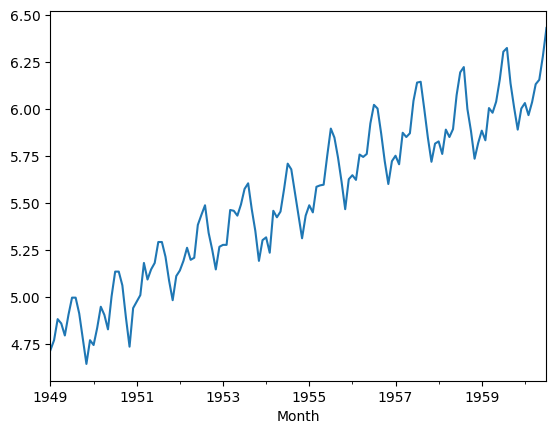

In [ ]:
# Plotting the transformed data.


df_bx.plot()

In [ ]:
# Differencing the boxcox to vary mean to constan mean

df_dif = df_bx.diff()

<Axes: xlabel='Month'>

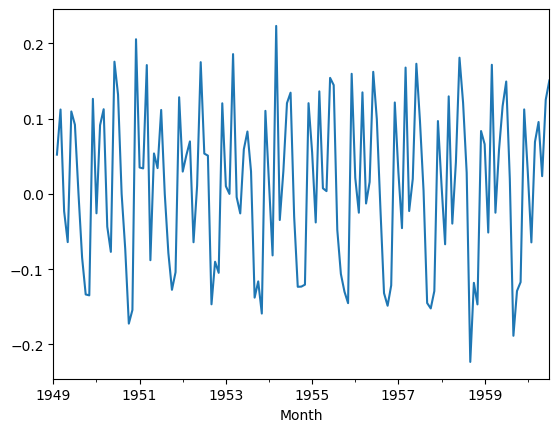

In [ ]:
# Plotting the boxcox and differenced data. 

df_dif.plot()

In [ ]:
# Hypotyhesis testing on a transformed data

hypothesis_testing(df_dif[1:])

Failed to Reject null hypothesis, Data is stationary


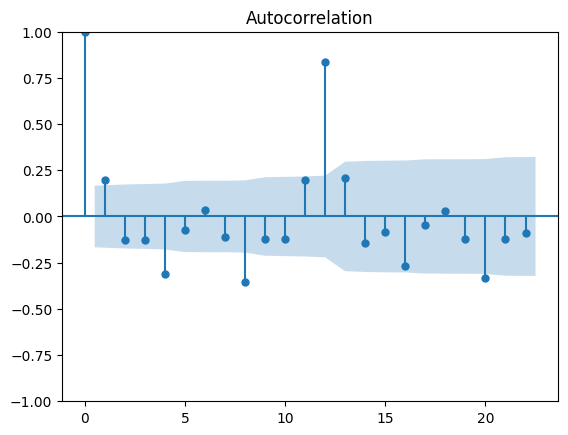

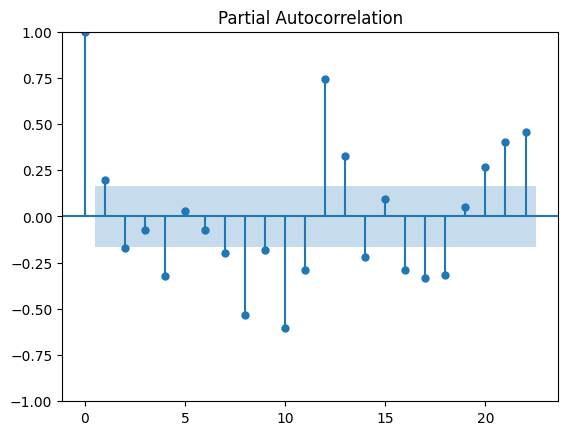

In [ ]:
# Checking the auto-correlatin of the data 

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_dif[1:]);
plot_pacf(df_dif[1: ]);

In [25]:
train_len = len(df_dif)


In [38]:
# We have a seasonal data. So, using SARIMAX model  

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(df_bx, order = (5, 0, 2), seasonal_order = (5, 0, 2, 12))  #Initializing the model with auto correlation value
sarima_model = sarima_model.fit()  

c:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:


sr_model_preds = sarima_model.predict(start = train_len, end = 144) # Forecasting the values from the past values

f_df = pd.concat([df_bx, sr_model_preds])  # Concatenating the train and forecast values. SARIMAX have pre configured differencing so passing boxcox transformed data.
exp_df = np.exp(f_df)  # Exponenting the dataset to get original data before boxcox



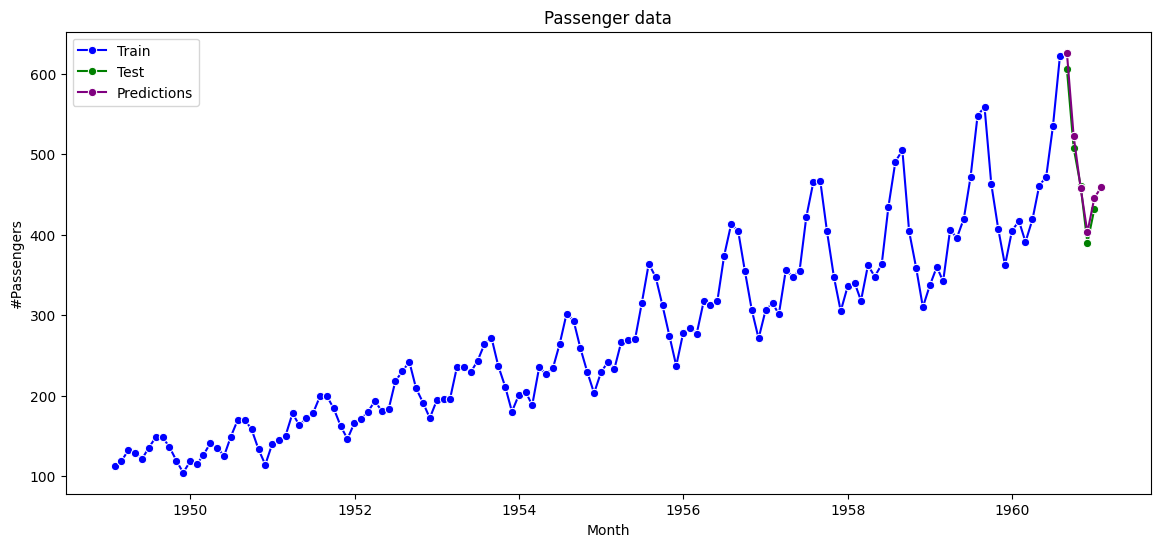

In [45]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = '#Passengers', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Month', y = '#Passengers', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = exp_df.index[train_len:], y = exp_df.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Passenger data');

In [ ]:
# Importing the metrics packages to evaluate the model 

from sklearn.metrics import *

In [ ]:
# Summarize the performance of the model on the test data using RMSE
rmse = np.sqrt(mean_squared_error(y_true = df_test, y_pred = exp_df.values[-5:]))

rmse = np.round(rmse, 2)

print(rmse)


57.72
